In [147]:
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
import time

BFS

In [148]:
def bfs(maze, start, goal):
    row, col = maze.shape
    visited = {start}
    queue = deque([start])
    parent = {start: None}

    while queue:
        node = queue.popleft()
        x, y = node

        if node == goal:
            path = []
            while node is not None:
                path.append(node)
                node = parent[node]
            return path[::-1]

        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx, ny = x + dx, y + dy
            if 0 <= nx < row and 0 <= ny < col:
                if maze[nx][ny] == 0 and (nx, ny) not in visited:
                    visited.add((nx, ny))
                    parent[(nx, ny)] = node
                    queue.append((nx, ny))
    return []

GA

In [149]:
def generate_population(pop_size, chromosome_length):
    population = np.random.randint(0, 4, (pop_size, chromosome_length))
    return population

In [150]:
def simulate (chromosome,maze,goal):
    x,y=0,0
    path = [(0, 0)]

    for gene in chromosome:
        newX,newY=x,y

        if gene==0: #up
            newX-=1
        if gene==1: #right
            newY+=1
        if gene==2: #down
            newX+=1
        if gene==3: #left
            newY-=1
        
        if(0<= newX < maze.shape[0]) and (0<= newY < maze.shape[1]) and maze[newX,newY]==0:
            x,y=newX,newY
            path.append((x, y))
            if (x, y) == goal:
                break
            
    return (x,y), path

In [151]:
def calculate_fitness(x,y,goal):
    distance = abs(goal[0]-x)+abs(goal[1]-y)
    score= -distance
    if distance==0:
        score+=1000
    return score

In [152]:
def tournament_selection(population, fitness_scores, tournament_size=3):

    selected_parents = []
    pop_size = len(population)
    
    for _ in range(pop_size):
        competitors_indices = np.random.randint(0, pop_size, tournament_size)
        
        best_idx = competitors_indices[0]
        for idx in competitors_indices:
            if fitness_scores[idx] > fitness_scores[best_idx]:
                best_idx = idx
        selected_parents.append(population[best_idx])
        
    return np.array(selected_parents)

In [153]:
def crossover(p1, p2):
    point = np.random.randint(1, len(p1) - 1)
        
    c1 = np.concatenate((p1[:point], p2[point:]))
    c2 = np.concatenate((p2[:point], p1[point:]))
    return c1, c2

In [154]:
def mutate(chromosome, mutation_rate=0.05):
    
    for i in range(len(chromosome)):
        if np.random.rand() < mutation_rate:
            chromosome[i] = np.random.randint(0, 4)
            
    return chromosome

Run Genetic Algorithm cycle

In [155]:
def run_genetic_algorithm(maze, goal, pop_size=100, max_generations=150, chromosome_length=200):
    
    population = generate_population(pop_size, chromosome_length)
    
    best_fitness_history = []
    best_overall_path = []
    best_overall_fitness = -float('inf')


    for gen in range(max_generations):
        fitness_scores = []
        paths = []
        
        for chromosome in population:
            final_pos, path = simulate(chromosome, maze, goal)
            fitness = calculate_fitness(final_pos[0], final_pos[1], goal)
            fitness_scores.append(fitness)
            paths.append(path)
            
        current_best_fitness = max(fitness_scores)
        best_index = fitness_scores.index(current_best_fitness)
        best_fitness_history.append(current_best_fitness)
        
        if current_best_fitness > best_overall_fitness:
            best_overall_fitness = current_best_fitness
            best_overall_path = paths[best_index]
        print(f"Generation {gen + 1} | Best Fitness: {current_best_fitness}")


        if current_best_fitness >= 1000:
            print(f"\n Goal Reached at Generation {gen+1}!")
            break
        
        if len(best_fitness_history) > 10 and len(set(best_fitness_history[-10:])) == 1:
            print(f"\n [TERMINATION] Convergence reached at Generation {gen+1}. Stuck in Local Optima.")
            break


        parents = tournament_selection(population, fitness_scores, tournament_size=3)    
        next_generation = []
        
        sorted_indices = np.argsort(fitness_scores)[::-1]
        next_generation.extend([population[sorted_indices[0]], population[sorted_indices[1]]])
        for i in range(0, len(parents) - 2, 2):
            p1 = parents[i]
            p2 = parents[i+1] if i+1 < len(parents) else parents[0]
            c1, c2 = crossover(p1, p2)
            
            c1 = mutate(c1, mutation_rate=0.05)
            c2 = mutate(c2, mutation_rate=0.05)
            next_generation.extend([c1, c2])
            
        population = np.array(next_generation[:pop_size])

    return best_overall_path

Main Code

In [156]:
maze = np.array([
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0],
    [1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]
])
goal = (19, 19)

Run BFS

In [157]:
start_bfs = time.time()

bfs_actual_path = bfs(maze, (0, 0), goal)
print("Best path using BFS:", bfs_actual_path)

end_bfs = time.time()
bfs_time = end_bfs - start_bfs
print(f"BFS Execution Time: {bfs_time:.5f} seconds")

Best path using BFS: [(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (2, 3), (2, 2), (3, 2), (4, 2), (4, 3), (4, 4), (4, 5), (3, 5), (2, 5), (1, 5), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (0, 12), (0, 13), (0, 14), (0, 15), (0, 16), (0, 17), (0, 18), (0, 19), (1, 19), (2, 19), (3, 19), (4, 19), (5, 19), (6, 19), (7, 19), (8, 19), (9, 19), (10, 19), (11, 19), (12, 19), (13, 19), (14, 19), (15, 19), (16, 19), (17, 19), (18, 19), (19, 19)]
BFS Execution Time: 0.00126 seconds


Run Genetic Algorithm

In [158]:
start_ga = time.time()

best_ga_path = run_genetic_algorithm(
    maze, 
    goal, 
    pop_size=100,            
    max_generations=200,     
    chromosome_length=200
)

end_ga = time.time()
ga_time = end_ga - start_ga
print(f"GA Execution Time: {ga_time:.5f} seconds")

Generation 1 | Best Fitness: -18
Generation 2 | Best Fitness: -13
Generation 3 | Best Fitness: -13
Generation 4 | Best Fitness: -13
Generation 5 | Best Fitness: -8
Generation 6 | Best Fitness: -6
Generation 7 | Best Fitness: -6
Generation 8 | Best Fitness: -5
Generation 9 | Best Fitness: -5
Generation 10 | Best Fitness: -5
Generation 11 | Best Fitness: 1000

 Goal Reached at Generation 11!
GA Execution Time: 0.37666 seconds


Visualization

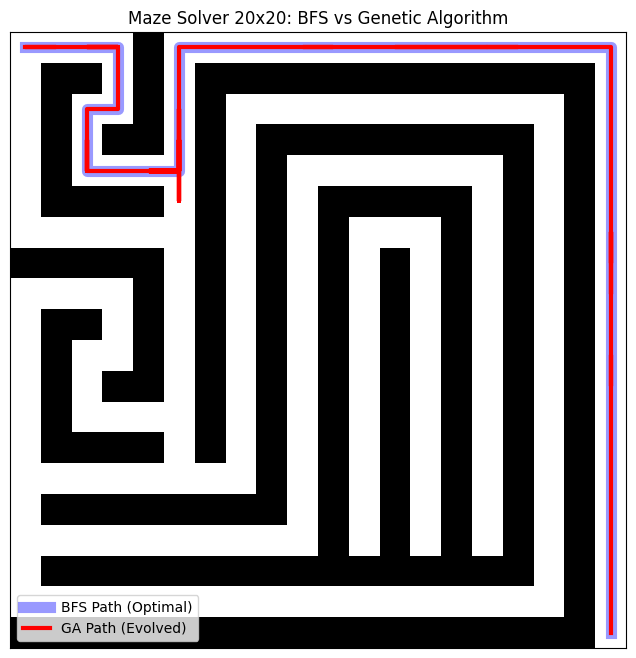

In [159]:
plt.figure(figsize=(8, 8))
plt.imshow(maze, cmap='binary')

if bfs_actual_path:
    bfs_y = [pos[0] for pos in bfs_actual_path]
    bfs_x = [pos[1] for pos in bfs_actual_path]
    plt.plot(bfs_x, bfs_y, color='blue', linewidth=8, alpha=0.4, label='BFS Path (Optimal)')

if best_ga_path:
    ga_y = [pos[0] for pos in best_ga_path]
    ga_x = [pos[1] for pos in best_ga_path]
    plt.plot(ga_x, ga_y, color='red', linewidth=3, linestyle='-', label='GA Path (Evolved)')

plt.title("Maze Solver 20x20: BFS vs Genetic Algorithm")
plt.legend()
plt.xticks([])
plt.yticks([])
plt.show()